In [2]:
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
tmax = xr.open_mfdataset("../../data/raw/Tmax*.nc", concat_dim="time",combine='nested') #temperatura, pressao, dewpoint
tmin = xr.open_mfdataset("../../data/raw/Tmin*.nc", concat_dim="time",combine='nested') #temperatura, pressao, dewpoint
pr = xr.open_mfdataset("../../data/raw/pr*.nc", concat_dim="time",combine='nested') #precipitacao
ds = xr.merge([tmax, tmin, pr]) 

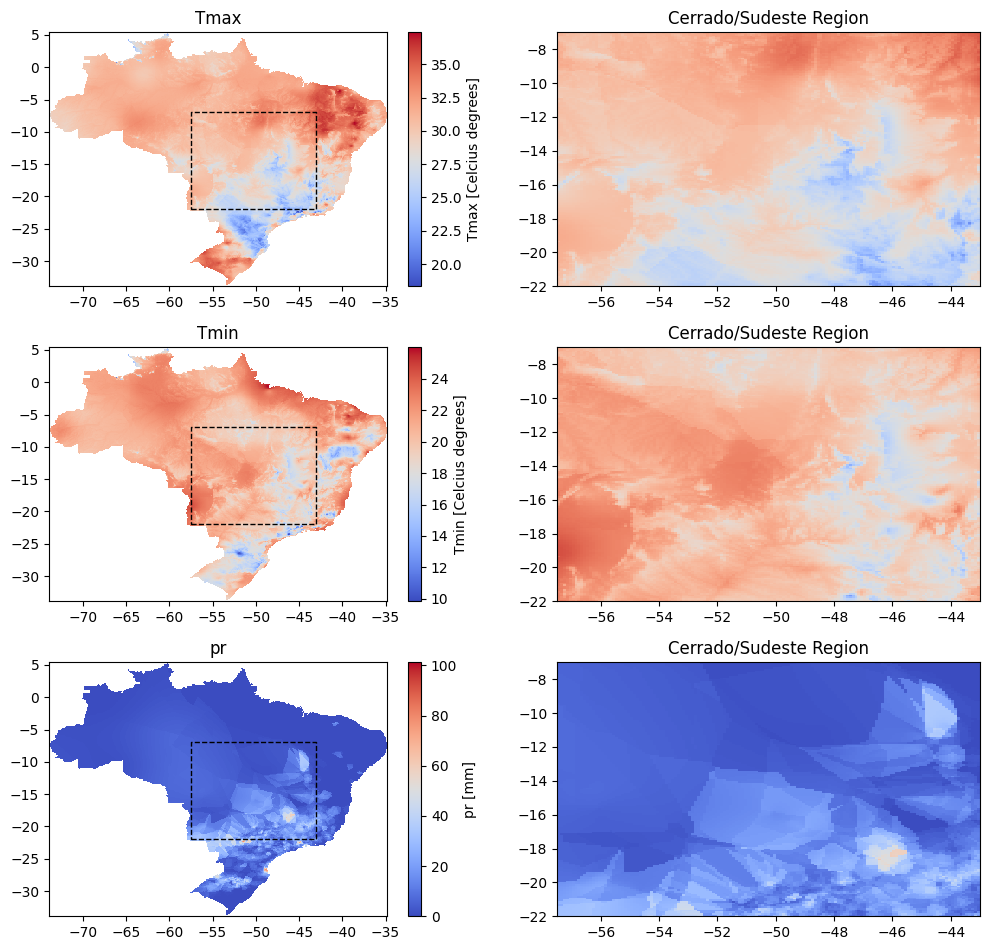

In [7]:
areas = {'Cerrado/Sudeste': {'latitude': [-22.0, -7.0], 'longitude': [-57.5, -43.0]}}

variables = [i for i in list(ds.variables.keys()) if i not in ['number', 'time', 'latitude','longitude','expver']]

fig, axs = plt.subplots(len(variables), 2, figsize=(10, 3.2*len(variables)))

for j, var in enumerate(variables):
        vmin = ds[var].isel(time=0).min().values.item()
        vmax = ds[var].isel(time=0).max().values.item()

        ds[var].isel(time=0).plot(ax=axs[j,0], cmap='coolwarm', add_colorbar=True, vmin=vmin, vmax=vmax)
        axs[j,0].set_title(ds[var].standard_name)
        axs[j,0].set_xlabel('')
        axs[j,0].set_ylabel('')

        for i, (area, coords) in enumerate(areas.items()):

                lat_min, lat_max = coords["latitude"]
                lon_min, lon_max = coords["longitude"]

                cropped = ds[var].sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
                cropped.isel(time=0).plot(ax=axs[j,i+1], cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
                axs[j,i+1].set_title(f"{area} Region")
                axs[j,i+1].set_xlabel('')
                axs[j,i+1].set_ylabel('')

                axs[j,0].plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                        [lat_min, lat_min, lat_max, lat_max, lat_min],
                        color='black', linewidth=1, linestyle='--')
                
plt.tight_layout()
plt.show()

estatisticas (normalizaçao):


In [6]:
for var in variables :
    cropped = ds[var].sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
    val = cropped.values
    print(var, val.mean(), val.std())

Tmax 31.149052846750973 3.275357473223305


distribuicao dados:

In [ ]:
# select data, convert dask arrays to numpy, flatten and drop NaNs
year = 2000
cropped = ds.sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))
tmin = cropped['Tmin'].values
tmax = cropped['Tmax'].values

# if these are dask arrays, compute them
try:
    tmin = tmin.compute()
    tmax = tmax.compute()
except Exception:
    pass

tmin = tmin.ravel()
tmax = tmax.ravel()
tmin = tmin[~np.isnan(tmin)]
tmax = tmax[~np.isnan(tmax)]

# use the same bin edges for both histograms so they are comparable
bins = np.histogram_bin_edges(np.concatenate([tmin, tmax]), bins=100)

plt.hist(tmin, bins=bins, color='skyblue', alpha=0.6, label='Tmin', edgecolor='black')
plt.hist(tmax, bins=bins, color='salmon',   alpha=0.5, label='Tmax', edgecolor='black')

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Histogram of Tmin and Tmax values (cropped region, 1961-2024)')
plt.legend()
plt.show()

exemplo medias:

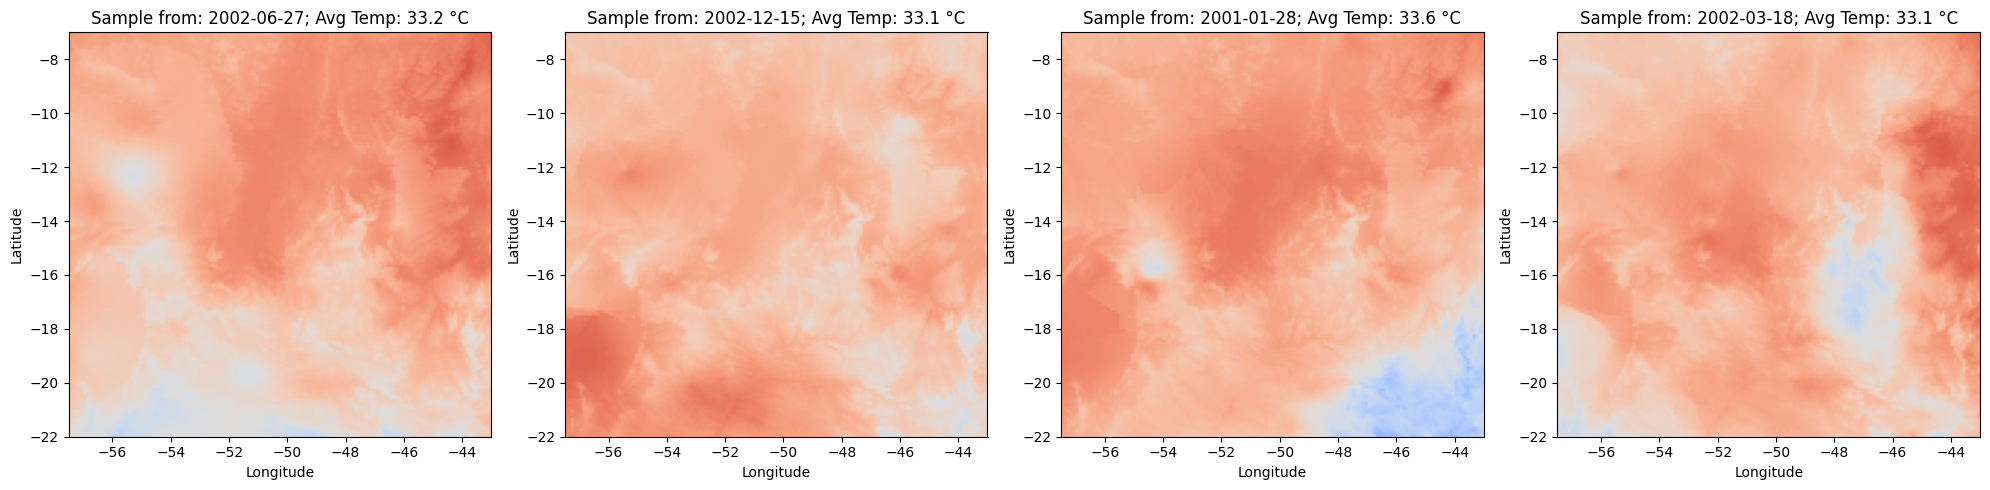

In [ ]:
tmax = cropped['Tmax'].sel(time=cropped.time.dt.year > year).values
medias = np.nanmean(tmax,axis=(1,2))
medias_34 = (medias>33) & (medias<35)
medias_34 =tmax[medias_34]
time= cropped.time.sel(time=cropped.time.dt.year > year).values

n = medias_34.shape[0]
k = min(8, n)
# idx = np.random.choice(n, size=k, replace=False)
idx = [542,
713,
27,
441]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.ravel()

vmin = np.nanmin(medias_34)
vmax = np.nanmax(medias_34)
extent = [lon_min, lon_max, lat_min, lat_max]

for ax, ii in zip(axes, idx):
    im = ax.imshow(medias_34[ii], cmap='coolwarm', vmin=vmin, vmax=vmax,
                   extent=extent, origin='lower', aspect='auto')
    ax.set_title(f"Sample from: {str(time[ii])[:10]}; Avg Temp: {np.nanmean(medias_34[ii]):.1f} °C")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

for ax in axes[k:]:
    ax.axis('off')

# fig.colorbar(im, ax=axes.tolist(), orientation='vertical', fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()